In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../project/dataset/synthetic_dataset_log.csv")

print(df.head())


             Timestamp       Src IP  Src Port     Dst IP  Dst Port Protocol  \
0  2026-02-02 20:19:21  172.16.0.69     17184  10.0.0.17       443      UDP   
1  2026-02-03 01:36:43    10.0.0.90     42317  10.0.0.11       443      TCP   
2  2026-02-03 12:06:37    10.0.0.38     14658  10.0.0.18        80      TCP   
3  2026-02-06 12:03:08  172.16.0.52     37978  10.0.0.19       443      UDP   
4  2026-02-07 13:38:25  172.16.0.35     42739  10.0.0.20        22      TCP   

   Flow Duration  Total Fwd Packets  Total Backward Packets  \
0          27054                135                      13   
1          74401                 20                      15   
2         138839                 17                      22   
3          46785                112                      10   
4          64539                 20                      12   

   Total Length of Fwd Packets  ...  FIN Flag Count  PSH Flag Count  \
0                      57620.0  ...               0               2   
1   

Label
BENIGN                  12400
DDoS                     1600
PortScan                 1600
DoS-Hulk                 1200
DoS-Slowloris            1000
SSH-Patator               800
FTP-Patator               600
Bot                       400
WebAttack-BruteForce      200
Infiltration              200
Name: count, dtype: int64


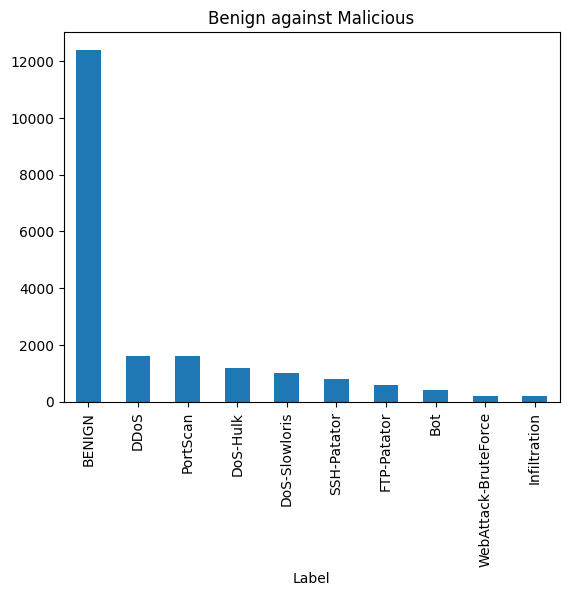

In [15]:
df['Label'].value_counts().plot(kind='bar')

print(df['Label'].value_counts())

plt.title("Benign against Malicious")
plt.show()


Ser tydelig at vi har størst andel trygg trafikk (BENIGN), vi har ca 7600 mistenksom trafikk. Ønsker å finne hva som er kjennetegn for datasettet, når det gjelder mistenksom trafikk. 

Hva vi kan se etter som er viktig å se på rundt mistenksom trafikk:
- Portnummer (Typ Port 80 (HTTP), Port 21 (FTP uten SFTP), Port 22 (SSH), Port 445 (SMB), Port 3389 (RDP))
- IP addresser -> Gjentakende IP-adresser for ulike angrep eller samme angrep
- Pakke størrelse
- Protokoller og hvilke som er utsatt for hvilke angrep


In [16]:
df.head(5)

,Timestamp,Src IP,Src Port,Dst IP,Dst Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,...,FIN Flag Count,PSH Flag Count,URG Flag Count,Down/Up Ratio,Packet Length Mean,Packet Length Std,Packet Length Max,Packet Length Min,Average Packet Size,Label
0,2026-02-02 20:19:21,172.16.0.69,17184,10.0.0.17,443,UDP,27054,135,13,57620.0,...,0,2,0,0.09,405.38,83.65,656.33,238.08,405.38,DDoS
1,2026-02-03 01:36:43,10.0.0.90,42317,10.0.0.11,443,TCP,74401,20,15,2930.0,...,1,1,0,0.72,476.47,463.29,1866.33,0.00,476.47,BENIGN
2,2026-02-03 12:06:37,10.0.0.38,14658,10.0.0.18,80,TCP,138839,17,22,7495.0,...,2,2,0,0.69,726.01,135.90,1133.72,454.20,726.01,BENIGN
3,2026-02-06 12:03:08,172.16.0.52,37978,10.0.0.19,443,UDP,46785,112,10,64444.0,...,0,0,0,0.07,551.54,181.61,1096.37,188.32,551.54,DDoS
4,2026-02-07 13:38:25,172.16.0.35,42739,10.0.0.20,22,TCP,64539,20,12,13965.0,...,0,3,0,1.71,532.30,536.26,2141.09,0.00,532.30,SSH-Patator


In [ ]:
clean = df[df['Label'] == "BENIGN"]
clean.to_csv("../../project/dataset/clean_dataset.csv", index=False)

In [40]:
ms = df[df["Label"] != "BENIGN"]
ms.to_csv("../../project/dataset/malicious_dataset.csv", index=False)
ms.head(5)

,Timestamp,Src IP,Src Port,Dst IP,Dst Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,...,FIN Flag Count,PSH Flag Count,URG Flag Count,Down/Up Ratio,Packet Length Mean,Packet Length Std,Packet Length Max,Packet Length Min,Average Packet Size,Label
0,2026-02-02 20:19:21,172.16.0.69,17184,10.0.0.17,443,UDP,27054,135,13,57620.0,...,0,2,0,0.09,405.38,83.65,656.33,238.08,405.38,DDoS
3,2026-02-06 12:03:08,172.16.0.52,37978,10.0.0.19,443,UDP,46785,112,10,64444.0,...,0,0,0,0.07,551.54,181.61,1096.37,188.32,551.54,DDoS
4,2026-02-07 13:38:25,172.16.0.35,42739,10.0.0.20,22,TCP,64539,20,12,13965.0,...,0,3,0,1.71,532.30,536.26,2141.09,0.00,532.30,SSH-Patator
5,2026-02-01 10:25:59,172.16.0.17,15529,10.0.0.15,8080,TCP,75256,222,40,106492.0,...,0,3,0,0.18,479.57,417.90,1733.27,0.00,479.57,DoS-Hulk
7,2026-02-02 14:56:25,172.16.0.45,30620,10.0.0.16,8080,TCP,50757,259,37,220452.0,...,1,8,0,0.32,805.48,401.95,2011.32,1.58,805.48,DoS-Hulk


In [45]:
x = ms['Dst Port'].value_counts()
y = ms['Src IP'].value_counts()
print(x, y)

Dst Port
80     1997
443    1063
22      801
21      541
53      475
       ... 
227       1
984       1
602       1
264       1
296       1
Name: count, Length: 841, dtype: int64 Src IP
172.16.0.16    94
172.16.0.21    94
172.16.0.27    92
172.16.0.35    89
172.16.0.28    86
               ..
10.0.0.77       2
10.0.0.87       2
10.0.0.71       1
10.0.0.41       1
10.0.0.51       1
Name: count, Length: 170, dtype: int64


Src IP       Dst Port
172.16.0.66  80          32
172.16.0.90  80          32
172.16.0.15  80          30
172.16.0.16  80          30
172.16.0.37  80          29
                         ..
172.16.0.20  296          1
172.16.0.15  512          1
172.16.0.16  89           1
172.16.0.86  155          1
172.16.0.70  371          1
Name: count, Length: 2677, dtype: int64


<Axes: xlabel='Label'>

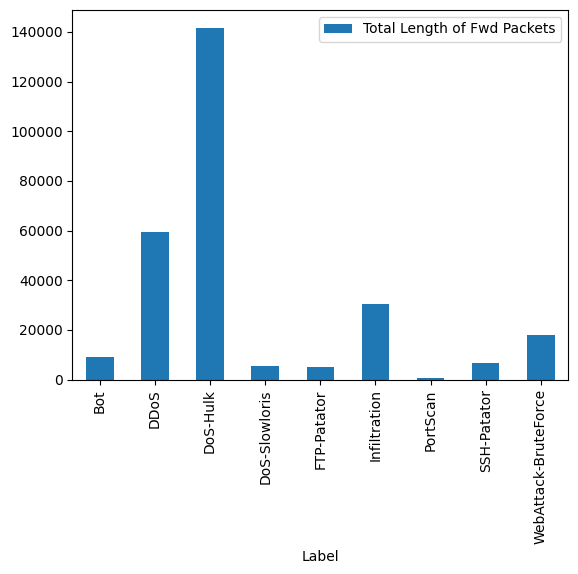

In [47]:
z = ms[['Src IP', 'Dst Port']].value_counts()
print(z)
ms[['Total Length of Fwd Packets', 'Label']].groupby('Label').mean().plot(kind='bar')


Datasett med kun malicious trafikk
7600 linjer med sårbar trafikk. 4000 av den trafikken er på destinasjonsportene 80 og 443. Ca 5000 er 80,443,22, 6000 ved 21 og 53. Dette er interessant.

På de 5 portene er det nesten 80% av all sårbar trafikk

Ser også at vi kan skille DoS angrep ut ifra total packet size, gir mening ut ifra teori. 

Deretter, skille mellom PortScan og DoS angrep skal være enkelt å verifisere ut ifra hvor forskjellige de er. Derimot, for å finne de store forskjellene mellom et DDoS og Dos-Hulk er vi nødt til å se litt dypere. 

Hva er forskjellen og hvor kan vi skille det tydeligst.

Forskjellen i ren DDoS og DoS angrep er at begge er denial-of-service angrep, derimot DoS er en maskin og en IP-connection som utfører angrepet. DDoS angrep er i all hovedsak at flere maskin danner et såkalt "Botnet", som utfører angrepet. Hulk står for HTTP unbearable load king. DoS-Hulk er egt bare HULK, men DoS presisering. Hulk er at man ønsker å overfylle CPU og Minne for å få nettserveren til å kræsje.  

Vil også etter EDA, fjerne Src IP og Dst IP for at modellen lærer angrep ut ifra pakkene og ulike metrikker, fremfor at en spesiell IP adresse gjorde angrepet. Dette er for å unngå ip-bias. 